#📌 Extracción

In [ ]:
import pandas as pd
import requests

# 1. Obtener los datos de la URL
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()

# 2. "Aplanar" el JSON para que los datos anidados se conviertan en columnas
df = pd.json_normalize(data)

# 3. Ver el resultado
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


#🔧 Transformación

In [ ]:

df.describe()


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [ ]:
df.shape

(7267, 21)

In [ ]:
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.isnull().sum())

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [ ]:
print(df['customer.gender'].value_counts())

print(df['account.Contract'].value_counts())

customer.gender
Male      3675
Female    3592
Name: count, dtype: int64
account.Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64


In [ ]:
# Convertir a numérico y transformar errores (espacios vacíos) en NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')


In [ ]:

print(df['account.Charges.Total'].isnull().sum())

11


In [ ]:
print(df.isnull().sum())

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [ ]:
# Ver las filas donde el Total es nulo
df[df['account.Charges.Total'].isnull()][['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']]

,customer.tenure,account.Charges.Monthly,account.Charges.Total
975,0,56.05,NaN
1775,0,20.00,NaN
1955,0,61.90,NaN
2075,0,19.70,NaN
2232,0,20.25,NaN
2308,0,25.35,NaN
2930,0,73.35,NaN
3134,0,25.75,NaN
3203,0,52.55,NaN
4169,0,80.85,NaN


In [ ]:
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

In [ ]:
print(df.isnull().sum())

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [ ]:
# 1. Creamos la columna Cuentas_Diarias
# Dividimos el cargo mensual por 30 y redondeamos a 2 decimales para que parezca dinero real
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

# 2. Verificamos la nueva columna junto a la original para validar
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [ ]:
# Definimos el diccionario de mapeo
mapeo = {
    'Yes': 1,
    'No': 0,
    'No phone service': 0,
    'No internet service': 0
}

# Aplicamos el cambio a todo el DataFrame
df = df.replace(mapeo)

# Verificamos los cambios en las primeras filas
df.head()

/tmp/ipykernel_1230/2788719433.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapeo)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [ ]:
# Diccionario de traducción basado en el diccionario
diccionario_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Tiene_Pareja',
    'customer.Dependents': 'Tiene_Dependientes',
    'customer.tenure': 'Meses_Permanencia',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'TV_Streaming',
    'internet.StreamingMovies': 'Peliculas_Streaming',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Digital',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total',
    'Cuentas_Diarias': 'Cargo_Diario' # La que creamos antes
}

# Aplicar el cambio
df = df.rename(columns=diccionario_columnas)

# Ver los nuevos nombres
print(df.columns)

Index(['ID_Cliente', 'Abandono', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico',
       'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online',
       'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'TV_Streaming', 'Peliculas_Streaming', 'Tipo_Contrato',
       'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total',
       'Cargo_Diario'],
      dtype='object')


In [ ]:
df.head()

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis

In [ ]:
# Seleccionamos las columnas numéricas clave
columnas_numericas = ['Meses_Permanencia', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

# Generamos el resumen estadístico
resumen = df[columnas_numericas].describe()

# Añadimos la mediana (que es el percentil 50) explícitamente para comparar
resumen.loc['mediana'] = df[columnas_numericas].median()

print(resumen)

         Meses_Permanencia  Cargo_Mensual  Cargo_Total  Cargo_Diario
count          7267.000000    7267.000000  7267.000000   7267.000000
mean             32.346498      64.720098  2277.182035      2.157292
std              24.571773      30.129572  2268.648587      1.004407
min               0.000000      18.250000     0.000000      0.610000
25%               9.000000      35.425000   396.200000      1.180000
50%              29.000000      70.300000  1389.200000      2.340000
75%              55.000000      89.875000  3778.525000      2.995000
max              72.000000     118.750000  8684.800000      3.960000
mediana          29.000000      70.300000  1389.200000      2.340000


In [ ]:
# Analizar la distribución del abandono (Churn)
print("Distribución de Abandono (1 = Se fue, 0 = Se quedó):")
print(df['Abandono'].value_counts(normalize=True) * 100) # En porcentaje

print("\nTipo de Contrato más común:")
print(df['Tipo_Contrato'].value_counts())

Distribución de Abandono (1 = Se fue, 0 = Se quedó):
Abandono
0    71.198569
1    25.719004
      3.082427
Name: proportion, dtype: float64

Tipo de Contrato más común:
Tipo_Contrato
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64


In [ ]:
# Ver las filas que están causando ese 3%
df[~df['Abandono'].isin([0, 1])]

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
30,0047-ZHDTW,,Female,0,0,0,11,1,1,Fiber optic,...,0,0,0,0,Month-to-month,1,Bank transfer (automatic),79.00,929.30,2.63
75,0120-YZLQA,,Male,0,0,0,71,1,0,0,...,0,0,0,0,Two year,1,Credit card (automatic),19.90,1355.10,0.66
96,0154-QYHJU,,Male,0,0,0,29,1,0,DSL,...,0,1,0,0,One year,1,Electronic check,58.75,1696.20,1.96
98,0162-RZGMZ,,Female,1,0,0,5,1,0,DSL,...,0,1,0,0,Month-to-month,0,Credit card (automatic),59.90,287.85,2.00
175,0274-VVQOQ,,Male,1,1,0,65,1,1,Fiber optic,...,1,0,1,1,One year,1,Bank transfer (automatic),103.15,6792.45,3.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,0,0,14,1,1,DSL,...,0,0,0,0,One year,1,Mailed check,54.25,773.20,1.81
7180,9872-RZQQB,,Female,0,1,0,49,0,0,DSL,...,0,0,1,0,Month-to-month,0,Bank transfer (automatic),40.65,2070.75,1.36
7211,9920-GNDMB,,Male,0,0,0,9,1,1,Fiber optic,...,0,0,0,0,Month-to-month,1,Electronic check,76.25,684.85,2.54
7239,9955-RVWSC,,Female,0,1,1,67,1,0,0,...,0,0,0,0,Two year,1,Bank transfer (automatic),19.25,1372.90,0.64


In [ ]:
# 1. Filtrar el DataFrame para mantener solo registros válidos (0 y 1)
df = df[df['Abandono'].isin([0, 1])].copy()

# 2. Asegurarnos de que el tipo de dato sea entero (int) para evitar decimales
df['Abandono'] = df['Abandono'].astype(int)

# 3. Verificar nuevamente la distribución
print("Nueva distribución de Abandono:")
print(df['Abandono'].value_counts(normalize=True) * 100)

Nueva distribución de Abandono:
Abandono
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [ ]:
print(f"Número de filas finales: {df.shape[0]}")

Número de filas finales: 7043


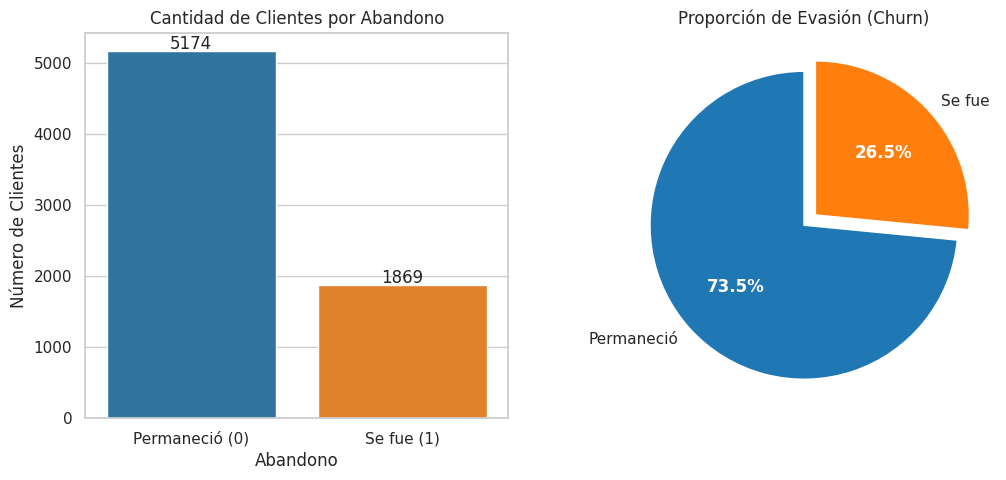

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colores = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(12, 5))

# --- GRÁFICO DE BARRAS ---
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Abandono', data=df, palette=colores, hue='Abandono', legend=False)
plt.title('Cantidad de Clientes por Abandono')
plt.xticks([0, 1], ['Permaneció (0)', 'Se fue (1)'])
plt.ylabel('Número de Clientes')

# Añadir etiquetas sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# --- GRÁFICO DE TORTA ---
plt.subplot(1, 2, 2)

patches, texts, autotexts = plt.pie(
    df['Abandono'].value_counts().sort_index(), # sort_index asegura que 0 sea el primero
    labels=['Permaneció', 'Se fue'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colores,
    explode=(0, 0.1)
)

# Ponemos los porcentajes internos en blanco
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

plt.title('Proporción de Evasión (Churn)')
plt.show()

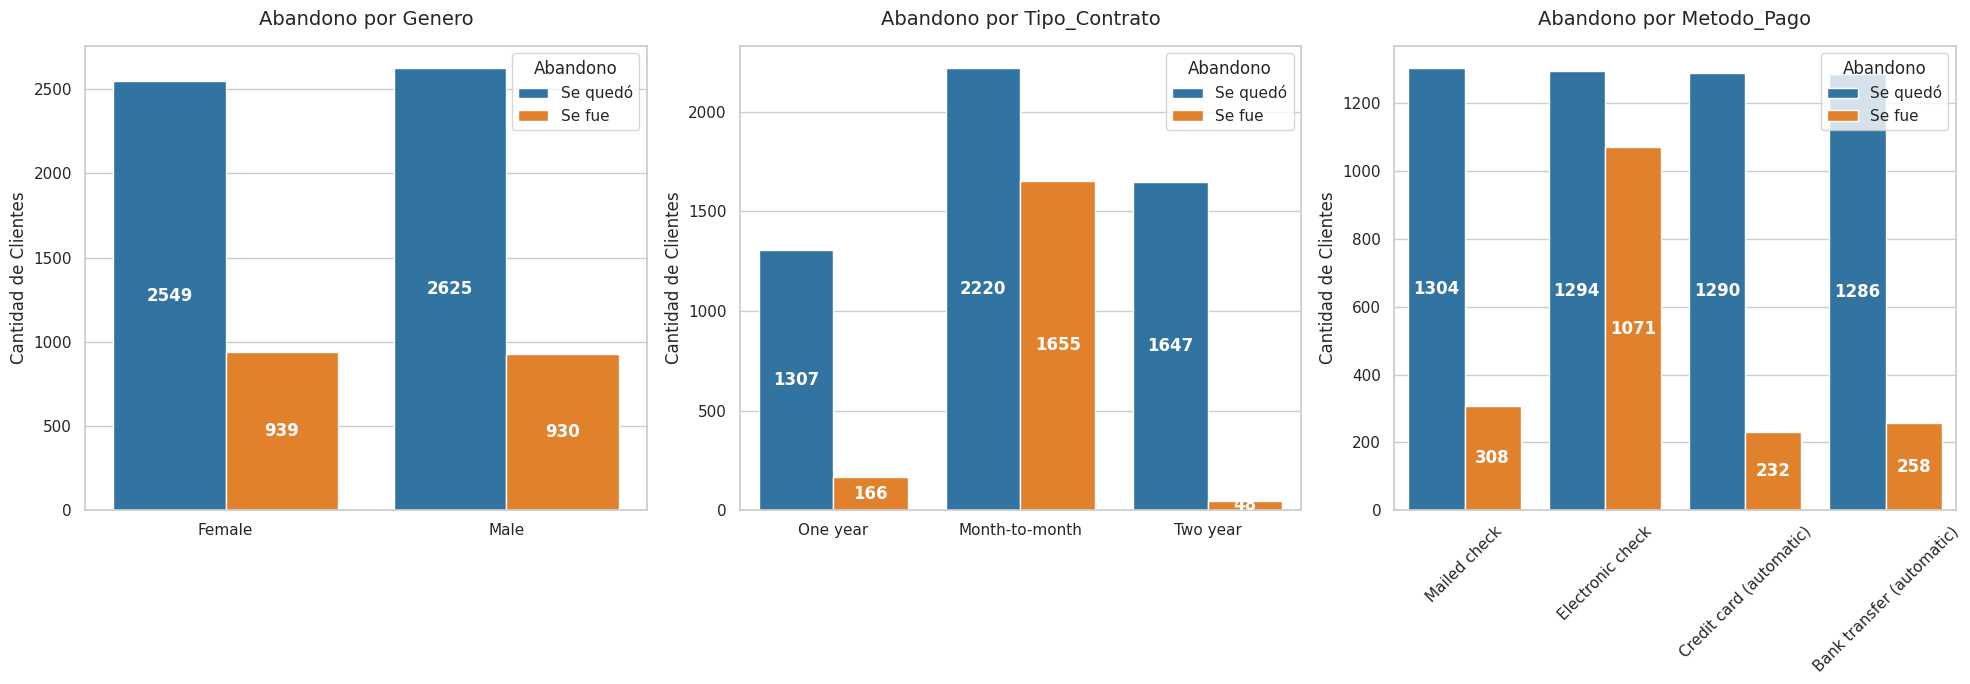

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorias = ['Genero', 'Tipo_Contrato', 'Metodo_Pago']
colores = ['#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))

for i, col in enumerate(categorias):
    # Crear el gráfico
    ax = sns.countplot(x=col, hue='Abandono', data=df, ax=axes[i], palette=colores)

    # --- AQUÍ ESTÁ EL TRUCO PARA LAS ETIQUETAS BLANCAS ---
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height / 2), # Posición central
                        ha='center', va='center',
                        color='white',
                        fontweight='bold',
                        fontsize=12,
                        xytext=(0, 0),
                        textcoords='offset points')
    # ----------------------------------------------------

    axes[i].set_title(f'Abandono por {col}', fontsize=14, pad=15)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='Abandono', labels=['Se quedó', 'Se fue'])

    if col == 'Metodo_Pago':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1230/532769351.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Permaneció', 'Se fue'])
/tmp/ipykernel_1230/532769351.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Permaneció', 'Se fue'])
/tmp/ipykernel_1230/532769351.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Permaneció', 'Se fue'])


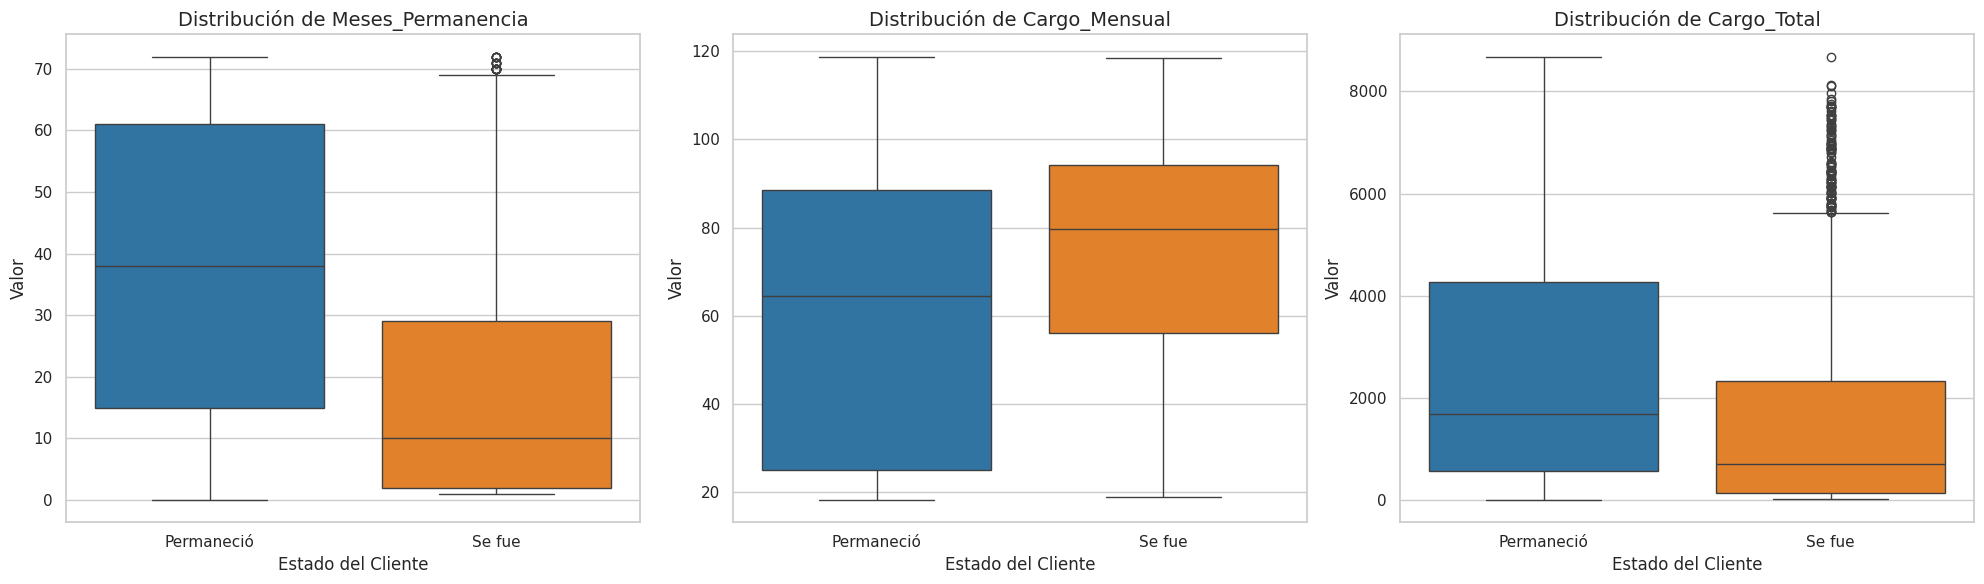

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de variables numéricas
variables_num = ['Meses_Permanencia', 'Cargo_Mensual', 'Cargo_Total']
colores = ['#1f77b4', '#ff7f0e'] # Azul (Se quedó), Naranja (Se fue)

# Crear la cuadrícula de gráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, var in enumerate(variables_num):
    # Crear el Boxplot

    sns.boxplot(x='Abandono', y=var, data=df, ax=axes[i], palette=colores, hue='Abandono', legend=False)

    # Personalización de cada gráfico
    axes[i].set_title(f'Distribución de {var}', fontsize=14)
    axes[i].set_xticklabels(['Permaneció', 'Se fue'])
    axes[i].set_xlabel('Estado del Cliente')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

In [ ]:
# Lista de servicios adicionales
servicios = ['Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo',
             'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming']

# Sumamos los servicios (como ya son 1 y 0, la suma es directa)
df['Total_Servicios'] = df[servicios].sum(axis=1)

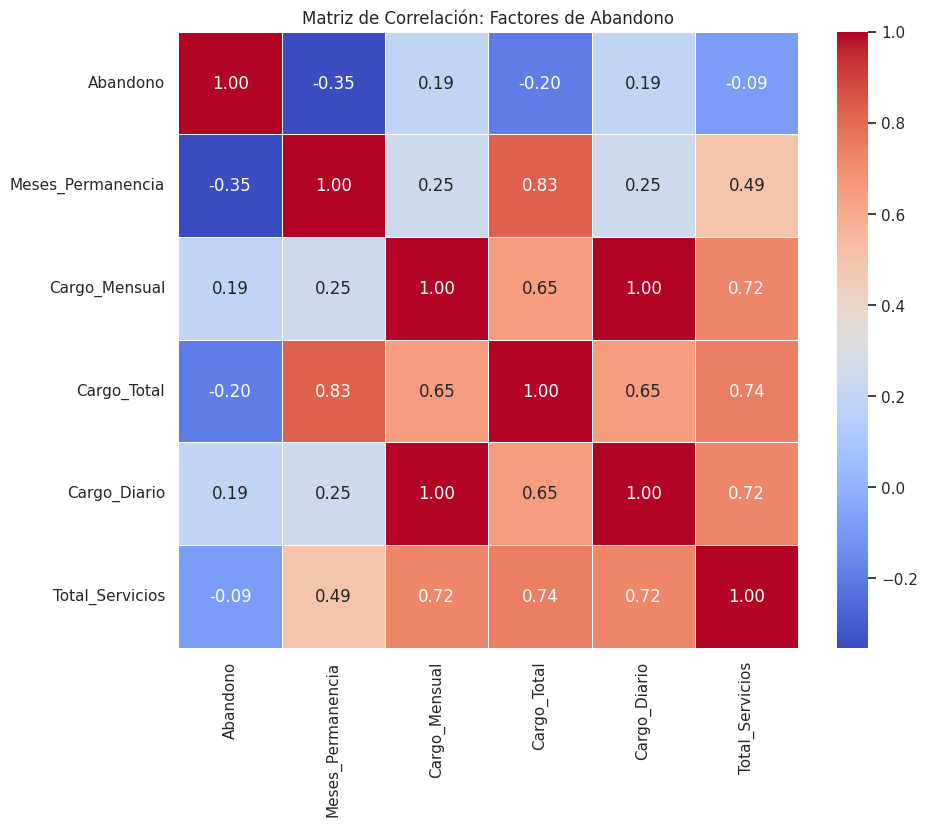

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas clave
vars_interes = ['Abandono', 'Meses_Permanencia', 'Cargo_Mensual',
                'Cargo_Total', 'Cargo_Diario', 'Total_Servicios']

matriz = df[vars_interes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Factores de Abandono')
plt.show()

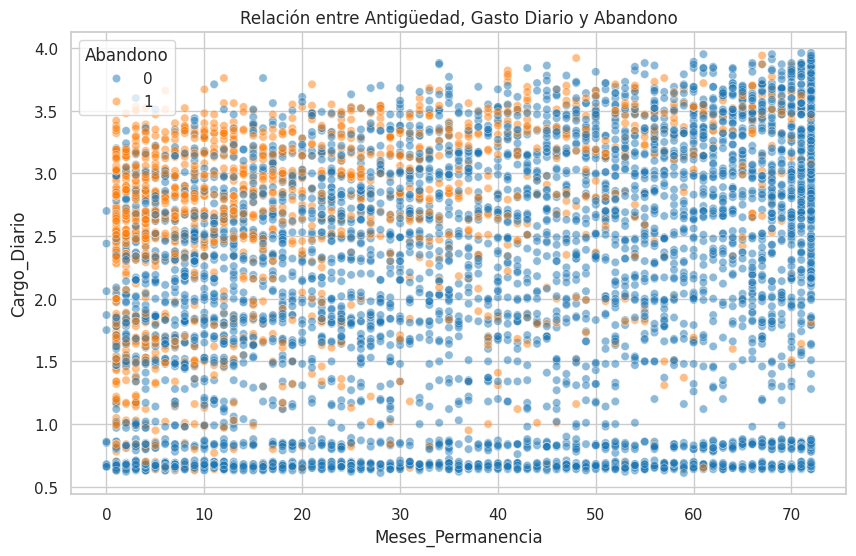

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Meses_Permanencia', y='Cargo_Diario', hue='Abandono', alpha=0.5, palette=['#1f77b4', '#ff7f0e'])
plt.title('Relación entre Antigüedad, Gasto Diario y Abandono')
plt.show()

#📄Informe final

# **📊 Informe de Análisis de Evasión (Churn): Proyecto TelecomX**
***1. 🎯 Introducción***

El objetivo de este análisis es comprender los factores que llevan a los clientes de TelecomX a cancelar sus servicios (Churn). La evasión de clientes es uno de los mayores desafíos en la industria de las telecomunicaciones, ya que adquirir un cliente nuevo es mucho más costoso que retener a uno actual. Este informe identifica patrones críticos para diseñar estrategias de retención efectivas.


***2. 🧹 Limpieza y Tratamiento de Datos***

- Importación y Aplanamiento: Los datos se extrajeron de una estructura JSON anidada utilizando json_normalize.

- Tratamiento de Nulos y Errores: Se identificó y eliminó un 3% de datos inconsistentes en la columna de Abandono (valores en blanco).

- Ingeniería de Características (Feature Engineering):

   - Se creó la columna Cargo_Diario para normalizar el gasto.

   - Se creó Total_Servicios para medir el nivel de adopción de productos.

- Estandarización: Se tradujeron las columnas al español y se codificaron las variables de texto ("Yes"/"No") a valores binarios (1/0) para facilitar el procesamiento matemático.


***3. 🔍 Análisis Exploratorio de Datos (EDA)***

A través de la visualización, identificamos tres pilares fundamentales en el comportamiento del cliente:

**Distribución del Churn:** El 26% de la base de clientes ha abandonado la empresa.


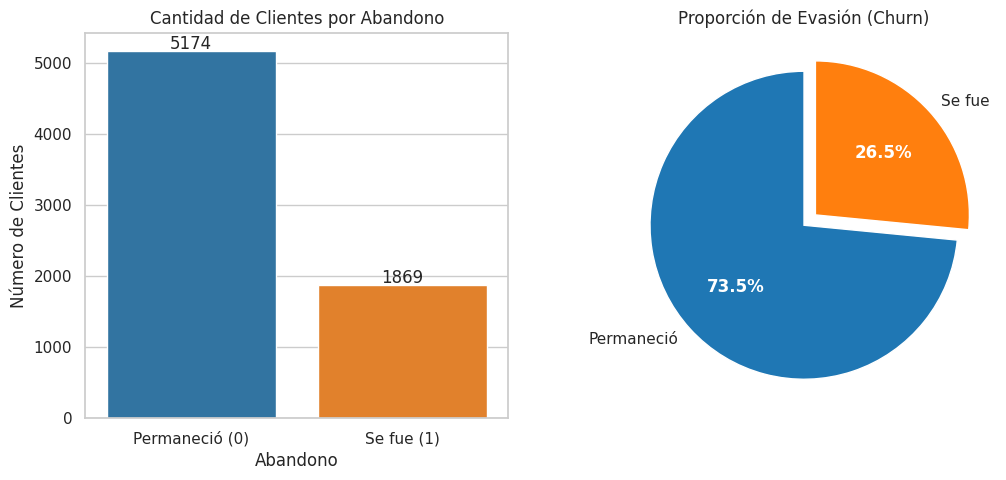

**Perfil Geográfico y de Género:** No se encontraron diferencias significativas de abandono entre hombres y mujeres, lo que indica que el problema es estructural del servicio o del precio, mas no demográfico.




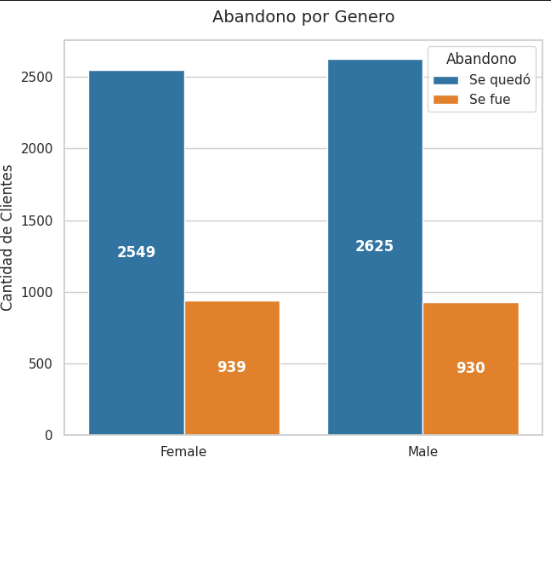

**Análisis Numérico (Boxplots):**

 Los clientes que se van tienen una permanencia mediana de solo 10 meses.


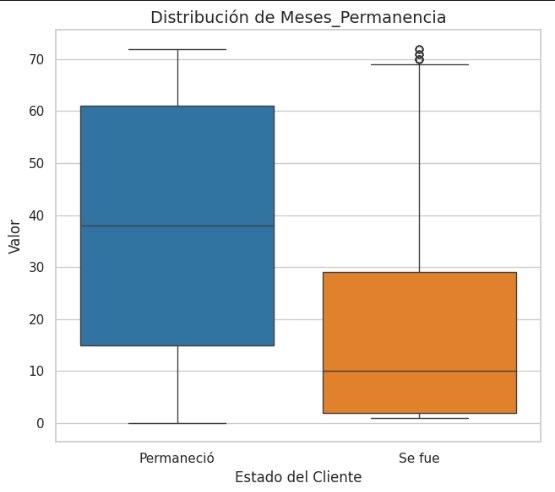


Los clientes que abandonan pagan en promedio de 15 a 20 unidades más mensualmente que los que se quedan.

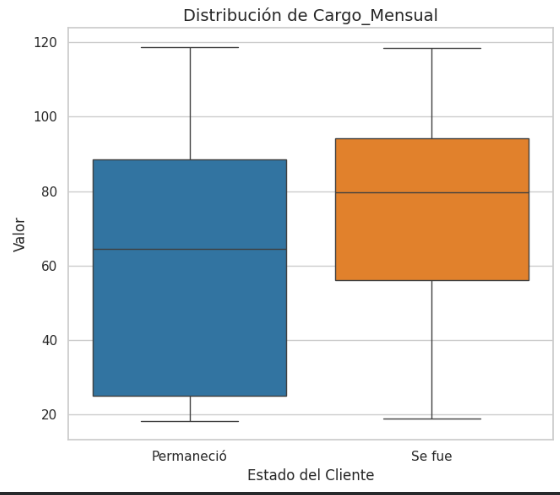

**El factor más crítico:** Meses de Permanencia (-0.35)
Este es el número negativo más grande en la columna de Abandono.

Existe una correlación negativa. Es decir, a medida que los "Meses de Permanencia" suben, la probabilidad de "Abandono" baja. Los clientes antiguos son leales. El peligro real está en los clientes nuevos.

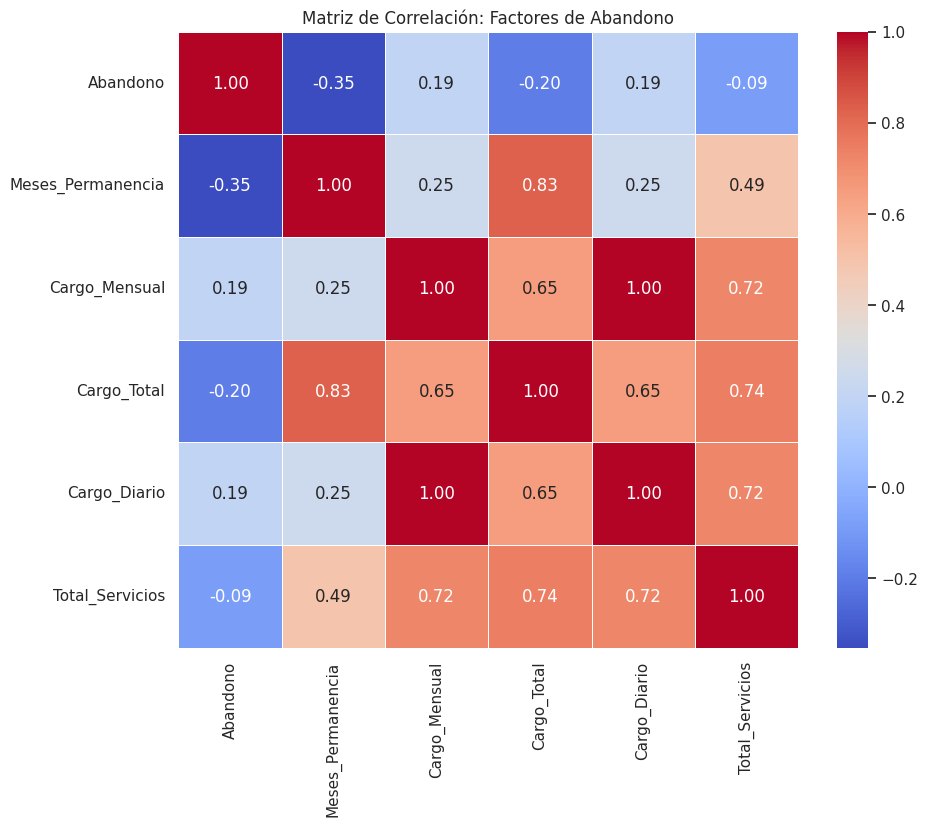

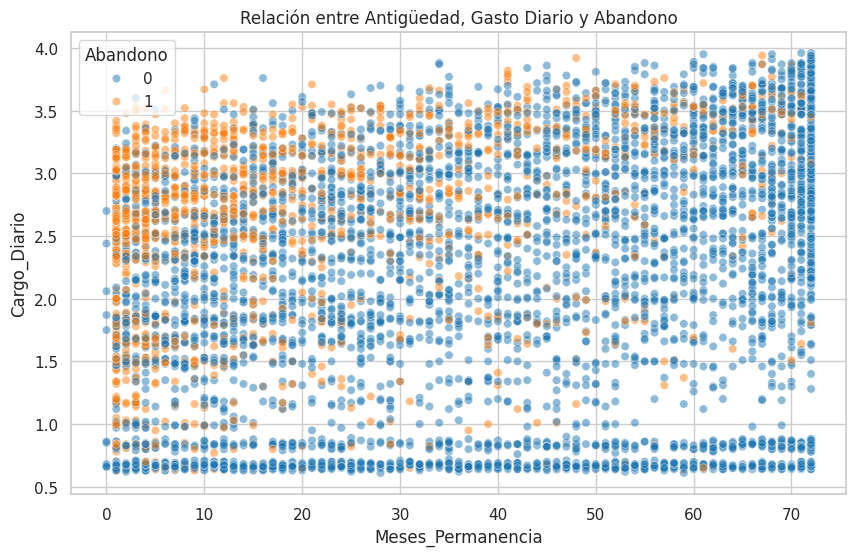

***4. 💡 Conclusiones e Insights***

La Matriz de Correlación y el análisis categórico revelaron los siguientes hallazgos clave:

**La "Curva de Peligro" de los 12 meses:** Existe una correlación negativa fuerte (-0.35) entre la permanencia y el abandono. Si un cliente supera el primer año, la probabilidad de que se vaya cae drásticamente.

**El "Impuesto a la Libertad":** Los contratos "Mes a Mes" presentan la mayor tasa de evasión. Los clientes valoran la flexibilidad, pero también son más sensibles a las ofertas de la competencia. Los clientes que se van suelen tener facturas mensuales más altas (alrededor de 80 en promedio) comparado con los que se quedan (alrededor de 65).

 ¡El precio es un factor de expulsión! Los clientes con planes más caros/completos son los más propensos a irse.

**Barrera de Precio**: Existe una correlación positiva (0.19) entre el costo mensual y el churn. Los planes premium tienen mayor rotación.

***5. 🚀 Recomendaciones Estratégicas***

Basado en los datos, se sugieren las siguientes acciones:

**Programa de "Fidelidad Temprana":** Implementar descuentos progresivos o beneficios exclusivos entre el mes 3 y el mes 9 de contrato para incentivar que el cliente cruce la barrera del primer año.

**Migración de Contratos:** Ofrecer incentivos (como servicios de streaming gratuitos por 3 meses) a los clientes "Mes a Mes" que acepten migrar a contratos anuales.

**Revisión de Planes Premium:** Analizar si el servicio de los planes de alto costo justifica el precio, o si es necesario crear un plan intermedio para evitar que estos clientes se filtren hacia la competencia por motivos económicos.